<a href="https://colab.research.google.com/github/subornakter/Image_processing_lab/blob/main/Image_Processing_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Reading, Displaying, and Inspecting a Digital Image**

In [ ]:
1.## Reading, Displaying, and Inspecting a Digital Image

import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
uploaded = files.upload()# Upload images

print("Uploaded files:", list(uploaded.keys()))# Check uploaded file names

# COLOR IMAGE
color_img = cv2.imread("colors.png")

if color_img is None:
    print("Error: color.png not found!")
else:
    print("\n----- COLOR IMAGE -----")
    print("Width:", color_img.shape[1])
    print("Height:", color_img.shape[0])
    print("Number of Channels:", color_img.shape[2])
    print("Data Type:", color_img.dtype)

    cv2_imshow(color_img)

# GRAYSCALE IMAGE

gray_img = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)

if gray_img is None:
    print("\nError: gray.jpg not found!")
else:
    print("\n----- GRAYSCALE IMAGE -----")
    print("Width:", gray_img.shape[1])
    print("Height:", gray_img.shape[0])
    print("Number of Channels: 1")
    print("Data Type:", gray_img.dtype)

    cv2_imshow(gray_img)

**2.Converting a Color Image to Grayscale**

Saving cat.jpg to cat.jpg


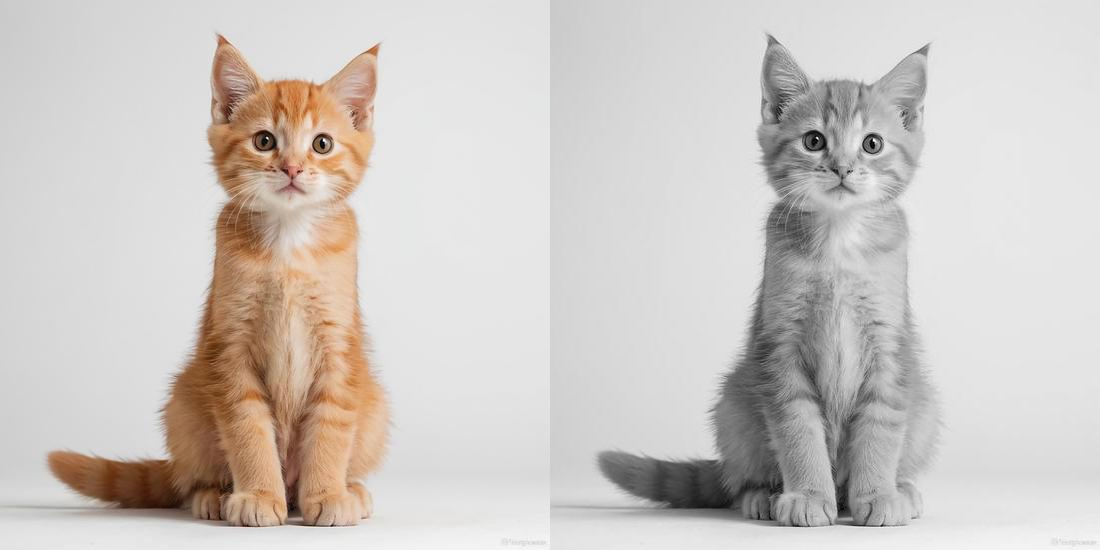

----- ORIGINAL COLOR IMAGE -----
Width: 550
Height: 550
Channels: 3
Data Type: uint8
Data Size (bytes): 907500

----- GRAYSCALE IMAGE -----
Width: 550
Height: 550
Channels: 1
Data Type: uint8
Data Size (bytes): 302500


In [5]:


import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload a color image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read color image
color_img = cv2.imread(filename)

# Convert color image to grayscale
gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

# Display images side by side
combined = cv2.hconcat([color_img, cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)])

cv2_imshow(combined)

# Image information
print("----- ORIGINAL COLOR IMAGE -----")
print("Width:", color_img.shape[1])
print("Height:", color_img.shape[0])
print("Channels:", color_img.shape[2])
print("Data Type:", color_img.dtype)
print("Data Size (bytes):", color_img.nbytes)

print("\n----- GRAYSCALE IMAGE -----")
print("Width:", gray_img.shape[1])
print("Height:", gray_img.shape[0])
print("Channels: 1")
print("Data Type:", gray_img.dtype)
print("Data Size (bytes):", gray_img.nbytes)

**3.Classifying an Unknown Image**

Saving cat.jpg to cat (1).jpg
----- IMAGE CLASSIFICATION -----
Result: Full-Color Image
Reason: The image has 3 different color channels (B, G, R).

Image:


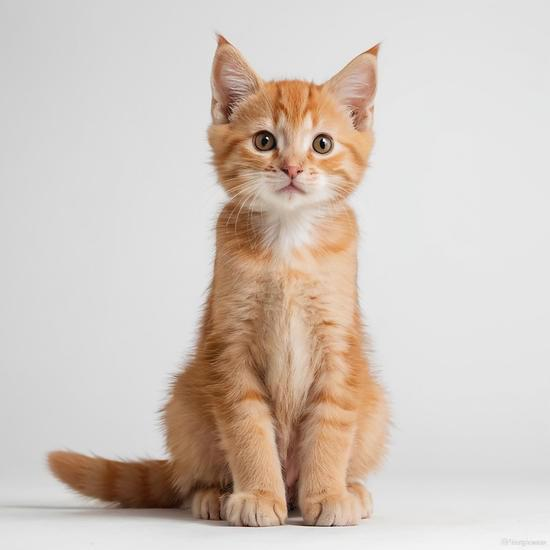

In [2]:

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload an image
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("Error: Image could not be loaded!")

else:
    print("----- IMAGE CLASSIFICATION -----")

    # Check if image is color
    if len(img.shape) == 3 and img.shape[2] == 3:

        b, g, r = cv2.split(img)

        # Check whether all channels are identical
        if np.array_equal(b, g) and np.array_equal(g, r):

            # It is actually grayscale
            gray = b
            unique_values = np.unique(gray)

            if len(unique_values) == 2:
                print("Result: Binary Image")
                print(
                    f"Reason: Detected {len(unique_values)} unique "
                    f"pixel values {unique_values}, so this is a binary image."
                )
            else:
                print("Result: Grayscale Image")
                print(
                    f"Reason: Detected {len(unique_values)} unique "
                    f"intensity values and the image has one intensity channel."
                )

        else:
            # Different B, G, R channels → Color
            print("Result: Full-Color Image")
            print(
                "Reason: The image has 3 different color channels "
                "(B, G, R)."
            )

    else:
        # Single-channel image
        gray = img
        unique_values = np.unique(gray)

        if len(unique_values) == 2:
            print("Result: Binary Image")
            print(
                f"Reason: Detected {len(unique_values)} unique "
                f"pixel values {unique_values}, so this is a binary image."
            )
        else:
            print("Result: Grayscale Image")
            print(
                f"Reason: Detected {len(unique_values)} unique "
                f"intensity values and the image has one intensity channel."
            )

    # Display original image
    print("\nImage:")
    cv2_imshow(img)

**4.Surveying Imaging Modalities**

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload 5 images
uploaded = files.upload()

# Image names
images = [
    ("X-ray Image", "x-ray.jpg",
     "Modality: X-ray imaging. Application: Used in medical diagnosis to detect bone fractures and abnormalities."),

    ("Satellite Image", "satellite.jpg",
     "Modality: Satellite/Remote-sensing imaging. Application: Used for weather monitoring, land mapping, and environmental observation."),

    ("Microscopy Image", "microscopy.jpg",
     "Modality: Microscopy imaging. Application: Used to observe cells, tissues, and microorganisms in biological research."),

    ("Ultrasound Image", "ultrasound.jpg",
     "Modality: Ultrasound imaging. Application: Used in medical diagnosis to examine internal organs and monitor pregnancy."),

    ("Infrared Image", "infrared.jpg",
     "Modality: Infrared imaging. Application: Used for thermal inspection, night vision, and detecting heat patterns.")
]

# Display each image
for title, filename, description in images:

    img = cv2.imread(filename)

    if img is None:
        print(f"\nError: {filename} not found!")
        continue

    print("\n================================")
    print(title)
    print("================================")

    cv2_imshow(img)

    print(description)


**5.Thresholding a Grayscale Image into Binary**

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload grayscale image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded!")

else:
    print("----- ORIGINAL GRAYSCALE IMAGE -----")
    cv2_imshow(img)

    # Three threshold values
    thresholds = [50, 128, 200]

    for t in thresholds:

        # Apply threshold
        _, binary = cv2.threshold(
            img,
            t,
            255,
            cv2.THRESH_BINARY
        )

        print(f"\n----- THRESHOLD = {t} -----")
        print(f"Pixels >= {t} → White (255)")
        print(f"Pixels < {t} → Black (0)")

        cv2_imshow(binary)

**6.Observing the Checkerboard Effect (Spatial Resolution)**

In [ ]:

import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload a grayscale image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded!")

else:
    print("----- ORIGINAL GRAYSCALE IMAGE -----")
    print("Size:", img.shape[1], "x", img.shape[0])
    print("Data Type:", img.dtype)
    print("Intensity Resolution: 8-bit (256 gray levels)")

    cv2_imshow(img)

    # Required spatial resolutions
    sizes = [128, 64, 32, 16]

    for size in sizes:

        # Reduce spatial resolution
        resized = cv2.resize(
            img,
            (size, size),
            interpolation=cv2.INTER_AREA
        )

        print(f"\n----- {size} x {size} -----")
        print("Spatial Resolution:", size, "x", size)
        print("Intensity Resolution: 8-bit (256 gray levels)")

        # Resize back to large size only for easy viewing
        display_img = cv2.resize(
            resized,
            (400, 400),
            interpolation=cv2.INTER_NEAREST
        )

        cv2_imshow(display_img)


**7.Observing False Contouring (Intensity Resolution)**

In [ ]:

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload a grayscale image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image as grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded!")

else:
    print("----- ORIGINAL IMAGE -----")
    print("Spatial Resolution:", img.shape[1], "x", img.shape[0])
    print("Intensity Resolution: 256 gray levels")
    cv2_imshow(img)

    # Required gray levels
    levels = [128, 64, 32, 16, 8, 4, 2]

    for L in levels:

        # Quantization
        step = 256 // L

        quantized = (img // step) * step

        # Keep values within 0-255
        quantized = np.clip(quantized, 0, 255).astype(np.uint8)

        print(f"\n----- {L} GRAY LEVELS -----")
        print("Spatial Resolution:",
              img.shape[1], "x", img.shape[0])
        print("Intensity Resolution:",
              L, "gray levels")

        cv2_imshow(quantized)

**8.Comparing Image Interpolation Methods**

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload a small image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("Error: Image could not be loaded!")

else:
    # Resize original image to 64 x 64
    small_img = cv2.resize(img, (64, 64))

    print("Original Image: 64 x 64")
    cv2_imshow(small_img)

    # Enlarge 4 times: 64 x 64 → 256 x 256

    nearest = cv2.resize(
        small_img,
        (256, 256),
        interpolation=cv2.INTER_NEAREST
    )

    bilinear = cv2.resize(
        small_img,
        (256, 256),
        interpolation=cv2.INTER_LINEAR
    )

    bicubic = cv2.resize(
        small_img,
        (256, 256),
        interpolation=cv2.INTER_CUBIC
    )

    # Display results
    print("----- NEAREST NEIGHBOR -----")
    cv2_imshow(nearest)

    print("----- BILINEAR -----")
    cv2_imshow(bilinear)

    print("----- BICUBIC -----")
    cv2_imshow(bicubic)


**9.Computing and Interpreting an Image Histogram**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload 3 images
uploaded = files.upload()

filenames = list(uploaded.keys())

for filename in filenames:

    # Read image as grayscale
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Image could not be loaded!")
        continue

    # Calculate histogram
    histogram = np.bincount(img.ravel(), minlength=256)

    # Display image
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(filename)
    plt.axis('off')

    # Display histogram
    plt.subplot(1, 2, 2)
    plt.bar(range(256), histogram, width=1)
    plt.title("Histogram")
    plt.xlabel("Intensity Level")
    plt.ylabel("Number of Pixels")

    plt.tight_layout()
    plt.show()

**10.Finding Pixel Neighbors**

In [ ]:
import cv2
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read grayscale image
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image could not be loaded!")

else:
    height, width = img.shape

    print("Image Size:", width, "x", height)

    # Function to find neighbors
    def find_neighbors(x, y, width, height):

        N4 = set()
        ND = set()

        # 4-neighbor positions
        four = [
            (x-1, y),   # Left
            (x+1, y),   # Right
            (x, y-1),   # Up
            (x, y+1)    # Down
        ]

        # Diagonal neighbor positions
        diagonal = [
            (x-1, y-1),
            (x-1, y+1),
            (x+1, y-1),
            (x+1, y+1)
        ]

        # Check 4-neighbors
        for nx, ny in four:
            if 0 <= nx < width and 0 <= ny < height:
                N4.add((nx, ny))

        # Check diagonal neighbors
        for nx, ny in diagonal:
            if 0 <= nx < width and 0 <= ny < height:
                ND.add((nx, ny))

        # 8-neighbors
        N8 = N4 | ND

        return N4, ND, N8

    # Test 1: Middle pixel
    middle_x = width // 2
    middle_y = height // 2

    # Test 2: Edge pixel
    edge_x = width // 2
    edge_y = 0

    # Test 3: Corner pixel
    corner_x = 0
    corner_y = 0

    tests = [
        ("Middle Pixel", middle_x, middle_y),
        ("Edge Pixel", edge_x, edge_y),
        ("Corner Pixel", corner_x, corner_y)
    ]

    for name, x, y in tests:

        N4, ND, N8 = find_neighbors(x, y, width, height)

        print("\n-----------------------------")
        print(name)
        print("Pixel:", (x, y))
        print("N4 =", N4)
        print("ND =", ND)
        print("N8 =", N8)

**11.Computing Distance Measures Between Pixels**

In [ ]:
import math

# Take coordinates as input
x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))

x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# Calculate differences
dx = abs(x1 - x2)
dy = abs(y1 - y2)

# Euclidean Distance
euclidean = math.sqrt(dx**2 + dy**2)

# City-block Distance (D4)
d4 = dx + dy

# Chessboard Distance (D8)
d8 = max(dx, dy)

# Display results
print("\n----- Distance Measures -----")
print("Pixel 1:", (x1, y1))
print("Pixel 2:", (x2, y2))

print("Euclidean Distance =", euclidean)
print("City-block Distance (D4) =", d4)
print("Chessboard Distance (D8) =", d8)

**12.Image Arithmetic and Change Detection**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload two images
uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 2:
    print("Please upload two images!")
else:
    # Read as grayscale
    img1 = cv2.imread(filenames[0], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(filenames[1], cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print("Error: Could not load images!")

    elif img1.shape != img2.shape:
        print("Error: Both images must have the same size!")

    else:
        # Convert to float
        A = img1.astype(np.float32)
        B = img2.astype(np.float32)

        # Addition
        addition = np.clip(A + B, 0, 255).astype(np.uint8)

        # Subtraction
        subtraction = np.abs(A - B).astype(np.uint8)

        # Multiplication
        multiplication = np.clip(A * B / 255, 0, 255).astype(np.uint8)

        # Division
        division = np.divide(A, B + 1) * 255
        division = np.clip(division, 0, 255).astype(np.uint8)

        # Display results
        titles = [
            "Image 1",
            "Image 2",
            "Addition",
            "Subtraction",
            "Multiplication",
            "Division"
        ]

        images = [
            img1,
            img2,
            addition,
            subtraction,
            multiplication,
            division
        ]

        plt.figure(figsize=(12, 8))

        for i in range(6):
            plt.subplot(2, 3, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i])
            plt.axis('off')

        plt.tight_layout()
        plt.show()

**13.Noise Reduction by Image Averaging**

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload a clean image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image as grayscale
clean = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if clean is None:
    print("Error: Image could not be loaded!")

else:
    # Convert to float for calculation
    clean_float = clean.astype(np.float32)

    noisy_images = []

    # Generate 20 noisy images
    for i in range(20):

        # Generate Gaussian noise
        noise = np.random.normal(
            loc=0,
            scale=25,
            size=clean.shape
        )

        # Add noise to the clean image
        noisy = clean_float + noise

        # Keep pixel values between 0 and 255
        noisy = np.clip(noisy, 0, 255)

        noisy_images.append(noisy)

    # Average all 20 noisy images pixel by pixel
    average_image = np.mean(noisy_images, axis=0)

    # Convert to uint8 for display
    noisy_one = noisy_images[0].astype(np.uint8)
    average_image = np.clip(average_image, 0, 255).astype(np.uint8)

    # Display one noisy image and final averaged image
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(noisy_one, cmap='gray')
    plt.title("One Noisy Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(average_image, cmap='gray')
    plt.title("Average of 20 Noisy Images")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**14.Set and Logical Operations on Binary Images**

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create two black binary images
img1 = np.zeros((400, 400), dtype=np.uint8)
img2 = np.zeros((400, 400), dtype=np.uint8)

# Image 1: White Circle
cv2.circle(img1, (180, 200), 100, 255, -1)

# Image 2: White Square
cv2.rectangle(img2, (150, 150), (350, 350), 255, -1)

# Logical operations
AND = cv2.bitwise_and(img1, img2)
OR = cv2.bitwise_or(img1, img2)
NOT_A = cv2.bitwise_not(img1)
XOR = cv2.bitwise_xor(img1, img2)

# Display results
titles = [
    "Image A: Circle",
    "Image B: Square",
    "AND",
    "OR",
    "NOT A",
    "XOR"
]

images = [
    img1,
    img2,
    AND,
    OR,
    NOT_A,
    XOR
]

plt.figure(figsize=(10, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

**15.Basic Geometric Transformations**

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("Error: Image could not be loaded!")

else:
    # Get image dimensions
    h, w = img.shape[:2]

    # ------------------------------------------------
    # (a) TRANSLATION
    # ------------------------------------------------
    tx = 50    # move 50 pixels to the right
    ty = 30    # move 30 pixels downward

    translation_matrix = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    translated = cv2.warpAffine(
        img,
        translation_matrix,
        (w, h)
    )

    # ------------------------------------------------
    # (b) ROTATION
    # ------------------------------------------------
    angle = 45

    center = (w // 2, h // 2)

    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        img,
        rotation_matrix,
        (w, h)
    )

    # ------------------------------------------------
    # (c) SCALING
    # ------------------------------------------------
    scale = 1.5

    scaled = cv2.resize(
        img,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_LINEAR
    )

    # ------------------------------------------------
    # DISPLAY
    # ------------------------------------------------

    plt.figure(figsize=(14, 8))

    # Original
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Translation
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
    plt.title("Translation")
    plt.axis("off")

    # Rotation
    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    plt.title("Rotation (45°)")
    plt.axis("off")

    # Scaling
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
    plt.title("Scaling (1.5×)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Print information
    print("----- IMAGE INFORMATION -----")
    print("Original Size :", w, "x", h)
    print("Translation   :", tx, "pixels right,", ty, "pixels down")
    print("Rotation      :", angle, "degrees")
    print("Scaling       :", scale, "times")
    print("Scaled Size   :", scaled.shape[1], "x", scaled.shape[0])